# Dialogue Summarization

This notebook implements a dialogue summarization workflow using the SAMSum dataset. JupyterLab was used to run the tests.

**Model:** BERT encoder-decoder, to meet project requirement.  

Run the notebook from top to bottom in a fresh JupyterLab kernel.

## 1. Environment Setup


In [1]:
%pip install -q -U datasets transformers evaluate rouge_score accelerate sentencepiece

Note: you may need to restart the kernel to use updated packages.


In [2]:
import gc
import random
from dataclasses import dataclass
from typing import Dict, List

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from datasets import load_dataset
from torch.utils.data import Dataset, DataLoader
from transformers import BertTokenizerFast, EncoderDecoderModel, GenerationConfig
from torch.optim import AdamW
from tqdm.auto import tqdm

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("PyTorch version:", torch.__version__)
print("Using device:", device)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch version: 2.10.0+cpu
Using device: cpu


## 2. Load the SAMSum Dataset

In [3]:
dataset = load_dataset("knkarthick/samsum")
train_df = dataset["train"].to_pandas()
val_df = dataset["validation"].to_pandas()
test_df = dataset["test"].to_pandas()

print("Training rows:", len(train_df))
print("Validation rows:", len(val_df))
print("Test rows:", len(test_df))
train_df.head()

Training rows: 14731
Validation rows: 818
Test rows: 819


,id,dialogue,summary
0,13818513,Amanda: I baked cookies. Do you want some?\nJ...,Amanda baked cookies and will bring Jerry some...
1,13728867,Olivia: Who are you voting for in this electio...,Olivia and Olivier are voting for liberals in ...
2,13681000,"Tim: Hi, what's up?\nKim: Bad mood tbh, I was ...",Kim may try the pomodoro technique recommended...
3,13730747,"Edward: Rachel, I think I'm in ove with Bella....",Edward thinks he is in love with Bella. Rachel...
4,13728094,Sam: hey overheard rick say something\nSam: i...,"Sam is confused, because he overheard Rick com..."


## 3. Exploratory Data Analysis

In [4]:
print(train_df.info())
print("\nMissing values:")
print(train_df[["dialogue", "summary"]].isna().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14731 entries, 0 to 14730
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   id        14731 non-null  object
 1   dialogue  14731 non-null  object
 2   summary   14731 non-null  object
dtypes: object(3)
memory usage: 345.4+ KB
None

Missing values:
dialogue    0
summary     0
dtype: int64


In [5]:
train_df["dialogue_word_count"] = train_df["dialogue"].str.split().str.len()
train_df["summary_word_count"] = train_df["summary"].str.split().str.len()
train_df[["dialogue_word_count", "summary_word_count"]].describe()

,dialogue_word_count,summary_word_count
count,14731.000000,14731.000000
mean,93.792750,20.318444
std,74.031937,11.153570
min,7.000000,1.000000
25%,39.000000,12.000000
50%,73.000000,18.000000
75%,128.000000,27.000000
max,803.000000,64.000000


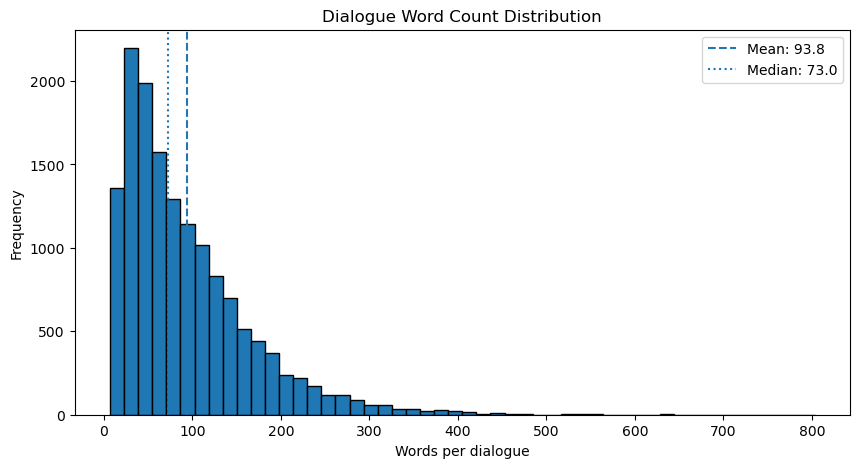

In [6]:
plt.figure(figsize=(10, 5))
plt.hist(train_df["dialogue_word_count"], bins=50, edgecolor="black")
plt.axvline(train_df["dialogue_word_count"].mean(), linestyle="--", label=f"Mean: {train_df['dialogue_word_count'].mean():.1f}")
plt.axvline(train_df["dialogue_word_count"].median(), linestyle=":", label=f"Median: {train_df['dialogue_word_count'].median():.1f}")
plt.title("Dialogue Word Count Distribution")
plt.xlabel("Words per dialogue")
plt.ylabel("Frequency")
plt.legend()
plt.show()

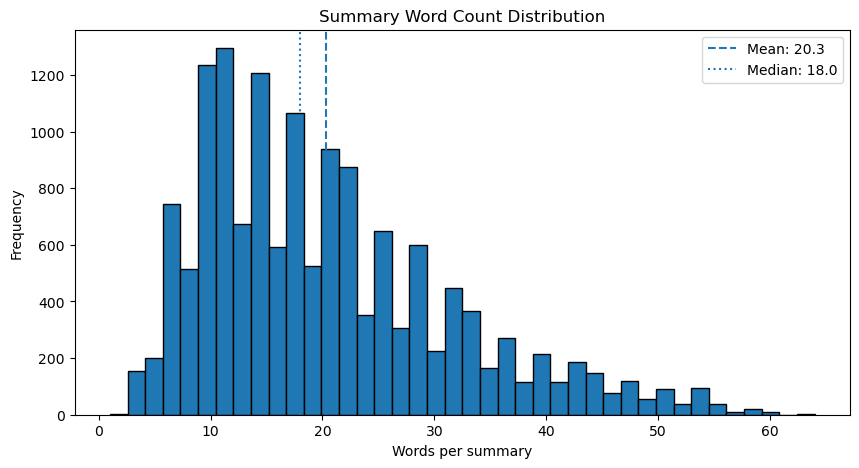

In [7]:
plt.figure(figsize=(10, 5))
plt.hist(train_df["summary_word_count"], bins=40, edgecolor="black")
plt.axvline(train_df["summary_word_count"].mean(), linestyle="--", label=f"Mean: {train_df['summary_word_count'].mean():.1f}")
plt.axvline(train_df["summary_word_count"].median(), linestyle=":", label=f"Median: {train_df['summary_word_count'].median():.1f}")
plt.title("Summary Word Count Distribution")
plt.xlabel("Words per summary")
plt.ylabel("Frequency")
plt.legend()
plt.show()

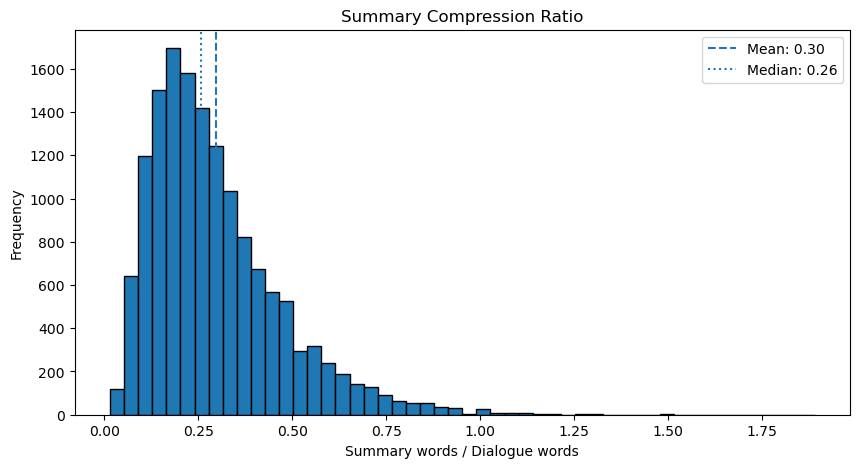

In [8]:
train_df["word_compression_ratio"] = train_df["summary_word_count"] / train_df["dialogue_word_count"]
plt.figure(figsize=(10, 5))
plt.hist(train_df["word_compression_ratio"], bins=50, edgecolor="black")
plt.axvline(train_df["word_compression_ratio"].mean(), linestyle="--", label=f"Mean: {train_df['word_compression_ratio'].mean():.2f}")
plt.axvline(train_df["word_compression_ratio"].median(), linestyle=":", label=f"Median: {train_df['word_compression_ratio'].median():.2f}")
plt.title("Summary Compression Ratio")
plt.xlabel("Summary words / Dialogue words")
plt.ylabel("Frequency")
plt.legend()
plt.show()

### Token-length and truncation analysis


In [9]:
tokenizer = BertTokenizerFast.from_pretrained("bert-base-uncased")

def token_count(text: str) -> int:
    return len(tokenizer.encode(text, add_special_tokens=True, truncation=False))

train_df["dialogue_token_count"] = train_df["dialogue"].apply(token_count)
train_df["summary_token_count"] = train_df["summary"].apply(token_count)
train_df[["dialogue_token_count", "summary_token_count"]].describe()

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (523 > 512). Running this sequence through the model will result in indexing errors


,dialogue_token_count,summary_token_count
count,14731.000000,14731.000000
mean,137.527866,27.267395
std,102.613637,13.771217
min,13.000000,3.000000
25%,61.000000,17.000000
50%,110.000000,24.000000
75%,185.000000,35.000000
max,1095.000000,83.000000


Dialogues over 512 tokens: 0.79%


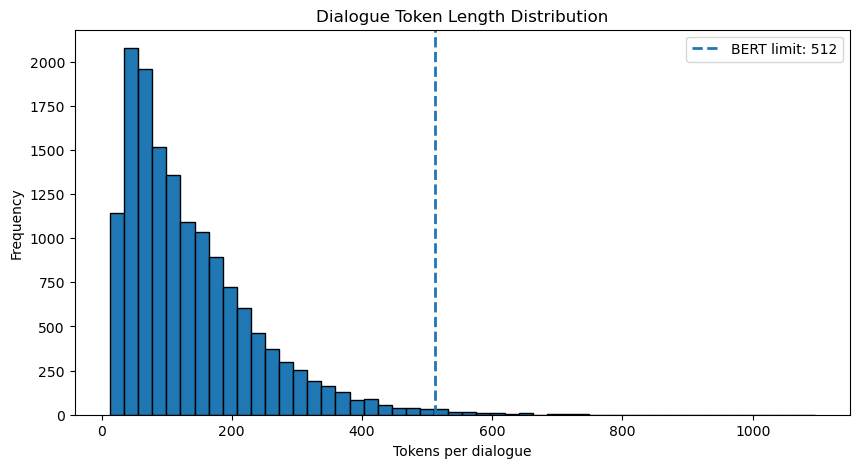

In [10]:
bert_limit = 512
pct_over_limit = (train_df["dialogue_token_count"] > bert_limit).mean() * 100
print(f"Dialogues over {bert_limit} tokens: {pct_over_limit:.2f}%")

plt.figure(figsize=(10, 5))
plt.hist(train_df["dialogue_token_count"], bins=50, edgecolor="black")
plt.axvline(bert_limit, linestyle="--", linewidth=2, label="BERT limit: 512")
plt.title("Dialogue Token Length Distribution")
plt.xlabel("Tokens per dialogue")
plt.ylabel("Frequency")
plt.legend()
plt.show()

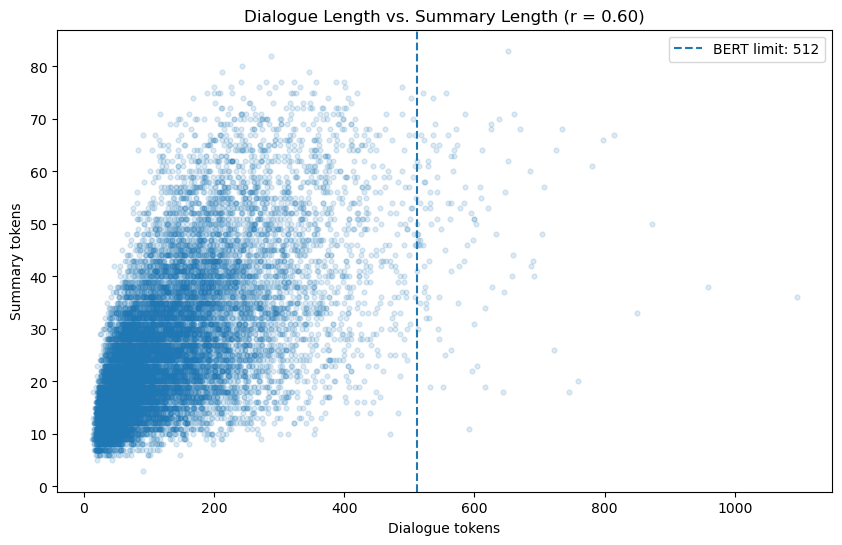

In [11]:
correlation = train_df["dialogue_token_count"].corr(train_df["summary_token_count"])
plt.figure(figsize=(10, 6))
plt.scatter(train_df["dialogue_token_count"], train_df["summary_token_count"], alpha=0.15, s=12)
plt.axvline(512, linestyle="--", label="BERT limit: 512")
plt.title(f"Dialogue Length vs. Summary Length (r = {correlation:.2f})")
plt.xlabel("Dialogue tokens")
plt.ylabel("Summary tokens")
plt.legend()
plt.show()

## 4. Memory-Conscious Data Preparation

In [12]:
TRAIN_SAMPLES = 3000
VAL_SAMPLES = 600
MAX_INPUT_LENGTH = 256
MAX_TARGET_LENGTH = 64
BATCH_SIZE = 2

train_small = dataset["train"].shuffle(seed=SEED).select(range(min(TRAIN_SAMPLES, len(dataset["train"]))))
val_small = dataset["validation"].shuffle(seed=SEED).select(range(min(VAL_SAMPLES, len(dataset["validation"]))))
print("Training subset:", len(train_small))
print("Validation subset:", len(val_small))

Training subset: 3000
Validation subset: 600


In [13]:
class DialogueSummaryDataset(Dataset):
    def __init__(self, hf_dataset):
        self.data = hf_dataset

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row = self.data[idx]
        return {"dialogue": row["dialogue"], "summary": row["summary"]}

@dataclass
class BertSeq2SeqCollator:
    tokenizer: BertTokenizerFast
    max_input_length: int = 256
    max_target_length: int = 64

    def __call__(self, examples: List[Dict[str, str]]) -> Dict[str, torch.Tensor]:
        dialogues = [item["dialogue"] for item in examples]
        summaries = [item["summary"] for item in examples]
        model_inputs = self.tokenizer(dialogues, max_length=self.max_input_length, truncation=True, padding=True, return_tensors="pt")
        label_batch = self.tokenizer(summaries, max_length=self.max_target_length, truncation=True, padding=True, return_tensors="pt")
        labels = label_batch["input_ids"]
        labels[labels == self.tokenizer.pad_token_id] = -100
        model_inputs["labels"] = labels
        return model_inputs

collator = BertSeq2SeqCollator(tokenizer, MAX_INPUT_LENGTH, MAX_TARGET_LENGTH)
train_loader = DataLoader(DialogueSummaryDataset(train_small), batch_size=BATCH_SIZE, shuffle=True, collate_fn=collator, num_workers=0)
val_loader = DataLoader(DialogueSummaryDataset(val_small), batch_size=BATCH_SIZE, shuffle=False, collate_fn=collator, num_workers=0)

sample_batch = next(iter(train_loader))
{k: tuple(v.shape) for k, v in sample_batch.items()}

{'input_ids': (2, 160),
 'token_type_ids': (2, 160),
 'attention_mask': (2, 160),
 'labels': (2, 21)}

## 5. BERT Encoder-Decoder Architecture

In [14]:
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

bert_model = EncoderDecoderModel.from_encoder_decoder_pretrained("bert-base-uncased", "bert-base-uncased")
bert_model.config.decoder_start_token_id = tokenizer.cls_token_id
bert_model.config.eos_token_id = tokenizer.sep_token_id
bert_model.config.pad_token_id = tokenizer.pad_token_id
bert_model.config.vocab_size = bert_model.config.encoder.vocab_size
bert_model.generation_config = GenerationConfig(
    decoder_start_token_id=tokenizer.cls_token_id,
    eos_token_id=tokenizer.sep_token_id,
    pad_token_id=tokenizer.pad_token_id,

    max_new_tokens=64,
    min_new_tokens=8,

    num_beams=4,
    length_penalty=1.2,
    repetition_penalty=1.15,
    no_repeat_ngram_size=3,

    early_stopping=True
)
bert_model.to(device)
print(f"Trainable parameters: {sum(p.numel() for p in bert_model.parameters() if p.requires_grad):,}")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

[transformers] BertLMHeadModel LOAD REPORT from: bert-base-uncased
Key                                                                | Status     | 
-------------------------------------------------------------------+------------+-
bert.pooler.dense.bias                                             | UNEXPECTED | 
bert.pooler.dense.weight                                           | UNEXPECTED | 
cls.seq_relationship.bias                                          | UNEXPECTED | 
cls.seq_relationship.weight                                        | UNEXPECTED | 
bert.encoder.layer.{0...11}.crossattention.output.dense.bias       | MISSING    | 
bert.encoder.layer.{0...11}.crossattention.self.query.bias         | MISSING    | 
bert.encoder.layer.{0...11}.crossattention.self.key.bias           | MISSING    | 
bert.encoder.layer.{0...11}.crossattention.self.value.weight       | MISSING    | 
bert.encoder.layer.{0...11}.crossattention.self.query.weight       | MISSING    | 
bert.encoder.layer.{

Trainable parameters: 247,363,386


## 6. Training and Validation

In [15]:
def train_one_epoch(
    model,
    data_loader,
    optimizer,
    device,
    gradient_accumulation_steps=4,
    scheduler=None
):
    model.train()
    total_loss = 0.0
    optimizer.zero_grad(set_to_none=True)

    progress = tqdm(data_loader, desc="Training")

    for step, batch in enumerate(progress, start=1):
        batch = {key: value.to(device) for key, value in batch.items()}

        outputs = model(**batch)
        raw_loss = outputs.loss
        loss = raw_loss / gradient_accumulation_steps
        loss.backward()

        if step % gradient_accumulation_steps == 0 or step == len(data_loader):
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

            optimizer.step()

            if scheduler is not None:
                scheduler.step()

            optimizer.zero_grad(set_to_none=True)

        total_loss += raw_loss.item()
        progress.set_postfix(loss=f"{raw_loss.item():.4f}")

    return total_loss / len(data_loader)

def evaluate_one_epoch(model, data_loader, device):
    model.eval()
    total_loss = 0.0
    with torch.no_grad():
        progress = tqdm(data_loader, desc="Validation")
        for batch in progress:
            batch = {key: value.to(device) for key, value in batch.items()}
            outputs = model(**batch)
            total_loss += outputs.loss.item()
            progress.set_postfix(loss=f"{outputs.loss.item():.4f}")
            del outputs, batch
    return total_loss / len(data_loader)

In [18]:
from torch.optim import AdamW
from transformers import get_linear_schedule_with_warmup
import copy


LEARNING_RATE = 2e-5
WEIGHT_DECAY = 0.01
NUM_EPOCHS = 5
GRADIENT_ACCUMULATION_STEPS = 4
WARMUP_RATIO = 0.10
EARLY_STOPPING_PATIENCE = 2


bert_optimizer = AdamW(
    bert_model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)


updates_per_epoch = (
    len(train_loader) + GRADIENT_ACCUMULATION_STEPS - 1
) // GRADIENT_ACCUMULATION_STEPS

total_training_steps = updates_per_epoch * NUM_EPOCHS

warmup_steps = int(
    WARMUP_RATIO * total_training_steps
)

scheduler = get_linear_schedule_with_warmup(
    bert_optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_training_steps
)


bert_train_losses = []
bert_val_losses = []

best_val_loss = float("inf")
best_model_state = None
epochs_without_improvement = 0

for epoch in range(NUM_EPOCHS):

    print(f"\n{'='*60}")
    print(f"Epoch {epoch + 1}/{NUM_EPOCHS}")
    print("="*60)

    train_loss = train_one_epoch(
        model=bert_model,
        data_loader=train_loader,
        optimizer=bert_optimizer,
        device=device,
        gradient_accumulation_steps=GRADIENT_ACCUMULATION_STEPS,
        scheduler=scheduler
    )

    val_loss = evaluate_one_epoch(
        model=bert_model,
        data_loader=val_loader,
        device=device
    )

    bert_train_losses.append(train_loss)
    bert_val_losses.append(val_loss)

    print(f"Training Loss   : {train_loss:.4f}")
    print(f"Validation Loss : {val_loss:.4f}")

    # Save best model
    if val_loss < best_val_loss:

        best_val_loss = val_loss
        best_model_state = copy.deepcopy(bert_model.state_dict())
        epochs_without_improvement = 0

        print("✓ New best model saved.")

    else:

        epochs_without_improvement += 1

        print(
            f"No improvement "
            f"({epochs_without_improvement}/{EARLY_STOPPING_PATIENCE})"
        )

        if epochs_without_improvement >= EARLY_STOPPING_PATIENCE:

            print("\nEarly stopping triggered.")
            break


if best_model_state is not None:
    bert_model.load_state_dict(best_model_state)

print("\nTraining Complete!")
print(f"Best Validation Loss: {best_val_loss:.4f}")


Epoch 1/5


Training:   0%|          | 0/1500 [00:00<?, ?it/s]

C:\Users\Ethan Moeller\anaconda3\Lib\site-packages\transformers\models\encoder_decoder\modeling_encoder_decoder.py:444: FutureWarning: Version v4.12.0 introduces a better way to train encoder-decoder models by computing the loss inside the encoder-decoder framework rather than in the decoder itself. You may observe training discrepancies if fine-tuning a model trained with versions anterior to 4.12.0. The decoder_input_ids are now created based on the labels, no need to pass them yourself anymore.
  warnings.warn(DEPRECATION_WARNING, FutureWarning)


Validation:   0%|          | 0/300 [00:00<?, ?it/s]

Training Loss   : 5.7581
Validation Loss : 4.1709
✓ New best model saved.

Epoch 2/5


...

Validation:   0%|          | 0/300 [00:00<?, ?it/s]

Training Loss   : 3.1254
Validation Loss : 3.5966
✓ New best model saved.

Epoch 5/5


Training:   0%|          | 0/1500 [00:00<?, ?it/s]

Validation:   0%|          | 0/300 [00:00<?, ?it/s]

Training Loss   : 2.8804
Validation Loss : 3.5766
✓ New best model saved.

Training Complete!
Best Validation Loss: 3.5766


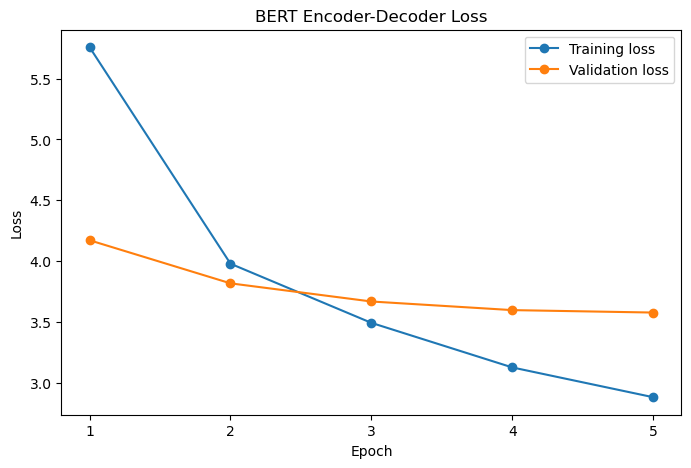

In [19]:
plt.figure(figsize=(8, 5))
epochs = range(1, len(bert_train_losses) + 1)
plt.plot(epochs, bert_train_losses, marker="o", label="Training loss")
plt.plot(epochs, bert_val_losses, marker="o", label="Validation loss")
plt.xlabel("Epoch")

plt.ylabel("Loss")
plt.title("BERT Encoder-Decoder Loss")
plt.xticks(list(epochs))
plt.legend()
plt.show()

## 7. Generate Sample Summaries

In [20]:
def generate_bert_summary(dialogue: str) -> str:
    bert_model.eval()
    inputs = tokenizer(dialogue, return_tensors="pt", max_length=MAX_INPUT_LENGTH, truncation=True)
    inputs = {key: value.to(device) for key, value in inputs.items()}
    with torch.no_grad():
        output_ids = bert_model.generate(**inputs)
    return tokenizer.decode(output_ids[0], skip_special_tokens=True)

for index in range(min(5, len(val_small))):
    example = val_small[index]
    prediction = generate_bert_summary(example["dialogue"])
    print("=" * 80)
    print(f"Example {index + 1}")
    print("\nDialogue:")
    print(example["dialogue"])
    print("\nReference summary:")
    print(example["summary"])
    print("\nGenerated summary:")
    print(prediction)
    print()

Example 1

Dialogue:
Victoria: God I'm really broke, I spent way to much this month 😫
Victoria: At least we get paid soon..
Magda: Yeah, don't remind me, I know the feeling
Magda: I just paid my car insurance, I feel robbed 😂
Victoria: Thankfully mine is paid for the rest of the year 🙏
Magda: 👌

Reference summary:
Magda and Victoria feel broke. 

Generated summary:
victoria ' s car broke down and she ' s going to work.

Example 2

Dialogue:
Antonio: The games tomorrow
Isiah: I aint goin
Antonio: What whyyy
Isiah: Melanies sick
Antonio: Man you promised, Rachel could stay with her
Isiah: She spends all the time at home I dont wanna leave her with this, there are two other kids, Ant
Antonio: Ehhh I knowwww
Isiah: Sorry
Antonio: Which of the guys would use your ticket, how do ya think
Isiah: Idk theyre all seem to be at work you need to ask
Antonio: I want to go there so baaad
Isiah: Just go alone
Antonio: Its not that fun, I did it once, not cool
Isiah: Your problem bro, I have a fuckin 

In [21]:
import random

num_examples = 5

indices = random.sample(range(len(val_small)), num_examples)

for index in indices:
    example = val_small[index]

    prediction = generate_bert_summary(example["dialogue"])

    print("=" * 80)
    print(f"Example {index}")

    print("\nDialogue:")
    print(example["dialogue"])

    print("\nReference Summary:")
    print(example["summary"])

    print("\nGenerated Summary:")
    print(prediction)
    print()

Example 114

Dialogue:
Rob: can you man the calls today
Sue: fine all day?
Rob: well I have the meeting in Plymouth so will probably be out of the office most of the day
Sue: ok thats fine, what time is the meeting?
Rob: need to be in the centre of Plymouth for about 11.30
Sue: no worries.. let me know how you get on
Rob: will do should be a good little job ongoing
Sue: great will we get Graham Mason on that?
Rob: yes I think so we can start after the new yer

Reference Summary:
Rob has a meeting in Plymouth at 11.30 and asks Sue to man the calls today. Rob expects a good job, engage Graham Mason in the job and start it after the New Year. 

Generated Summary:
rob will be in the office in 10 minutes. he will be there in 5 minutes.

Example 25

Dialogue:
Dorothy: Honey, don't go into the garage
Peter: Why not?
Dorothy: there are all those spare knick knacks there 
Peter: Oh, you're right.
Dorothy: I have to get rid of them
Peter: But the car is small, maybe I'll fit it anyways?
Dorothy:

## 8. ROUGE Evaluation

In [26]:
import evaluate
from tqdm.auto import tqdm

rouge = evaluate.load("rouge")


ROUGE_EXAMPLES = min(25, len(val_small))

predictions = []
references = []


for index in tqdm(
    range(ROUGE_EXAMPLES),
    desc="Generating summaries"
):
    example = val_small[index]

    generated_summary = generate_bert_summary(
        example["dialogue"]
    )

    predictions.append(generated_summary)
    references.append(example["summary"])

# Calculate ROUGE scores
rouge_results = rouge.compute(
    predictions=predictions,
    references=references,
    use_stemmer=True
)

# Convert results into a table
rouge_table = pd.DataFrame({
    "Metric": [
        "ROUGE-1",
        "ROUGE-2",
        "ROUGE-L",
        "ROUGE-Lsum"
    ],
    "Score": [
        float(rouge_results["rouge1"]),
        float(rouge_results["rouge2"]),
        float(rouge_results["rougeL"]),
        float(rouge_results["rougeLsum"])
    ]
})

rouge_table["Percentage"] = (
    rouge_table["Score"] * 100
).round(2)

# Format the raw score
rouge_table["Score"] = rouge_table["Score"].round(4)

print(f"ROUGE evaluation based on {ROUGE_EXAMPLES} validation examples:")
display(rouge_table)

Generating summaries:   0%|          | 0/25 [00:00<?, ?it/s]

ROUGE evaluation based on 25 validation examples:


,Metric,Score,Percentage
0,ROUGE-1,0.1890,18.90
1,ROUGE-2,0.0362,3.62
2,ROUGE-L,0.1579,15.79
3,ROUGE-Lsum,0.1584,15.84


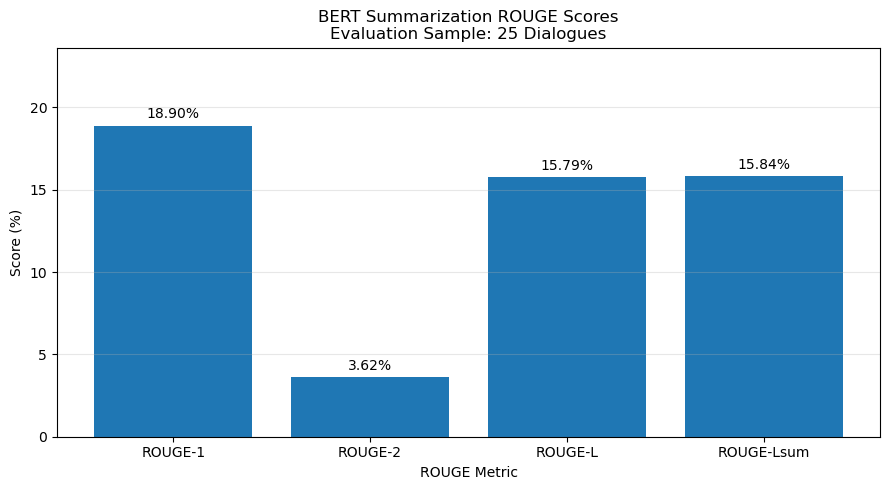

In [27]:
plt.figure(figsize=(9, 5))

bars = plt.bar(
    rouge_table["Metric"],
    rouge_table["Percentage"]
)

plt.title(
    f"BERT Summarization ROUGE Scores\n"
    f"Evaluation Sample: {ROUGE_EXAMPLES} Dialogues"
)
plt.xlabel("ROUGE Metric")
plt.ylabel("Score (%)")
plt.ylim(
    0,
    max(rouge_table["Percentage"]) * 1.25
)
plt.grid(axis="y", alpha=0.3)

for bar, value in zip(
    bars,
    rouge_table["Percentage"]
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.25,
        f"{value:.2f}%",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

## 9. Save the Fine-Tuned Model

In [23]:
SAVE_DIR = "bert_samsum_proof_of_concept"
bert_model.save_pretrained(SAVE_DIR)
tokenizer.save_pretrained(SAVE_DIR)
print(f"Saved model and tokenizer to: {SAVE_DIR}")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved model and tokenizer to: bert_samsum_proof_of_concept


## 10. Conclusions and Limitations


The model performed best on ROUGE-1, scoring 18.9%, which shows it was able to pick up on many of the important words and main topics in the conversations. However, the ROUGE-2 score of 3.62% suggests it had trouble generating natural multi-word phrases, and the ROUGE-L score of 15.8% shows it only captured part of the structure of the human-written summaries. Overall, this project showed that a BERT encoder-decoder can work as a proof of concept for dialogue summarization, but it also highlighted that BERT isn't ideal for generating fluent text. With more training, additional hyperparameter tuning, or by using models built specifically for text generation like BART, T5, or GPT-2, the summaries would likely become much more accurate and natural.